# Wireless Networking and Mobile Computing

### Prerequisites

This Jupyter Notebook has been tested with Visual Studio Code, running in a local Python environment.

**Installs**

In [ ]:
# --- Installs: ensure required packages are available ---
%pip install numpy pandas matplotlib --upgrade pip --quiet

**Imports**

In [1]:
# --- Imports: libraries used in this notebook ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import subprocess
import re
import xml.etree.ElementTree as ET
import sys

**Declarations**

Set the variables below and run the generation cell. 

- `scenario` is the path to the `.xml` scenario file that will be simulated.

In [2]:
# --- Declarations: editable variables for students ---
scenario = "./jemula-project/jemula802/scenarios/ETH_Course/WNMC_Resource_Sharing.xml"

### 1 Simulation Results

#### 1.1. Folder Location
We dynamically extract the folder location from the property `Path2Results`.

In [4]:
# --- Locate Results Folder ---
tree = ET.parse(scenario)
root = tree.getroot()
path_elem = root.find(".//JE802StatEval")
path2results = path_elem.get("Path2Results") if path_elem is not None else None

if not path2results:
    raise ValueError("Path2Results not found in scenario XML")

print(f"Found results folder: {path2results}")

# List contents (cross-platform)
if os.path.isdir(path2results):
    print(f"\nContents of {path2results}:")
    for f in os.listdir(path2results)[:10]:
        print("  - ", f)
    print("  -  ...")
else:
    print(f"\nResults folder {path2results} does not exist yet.")

# Change Directory to Results Folder
if os.path.isdir(path2results):
    os.chdir(path2results)
    print(f"Changed directory to {path2results}")
else:
    print(f"Results folder {path2results} not found.")

Found results folder: Results/MYALG_YOURALG/

Contents of Results/MYALG_YOURALG/:
  -  thrp_SA1_DA2_AC1_ID_15_saturation__End.csv
  -  thrp_SA1_DA2_AC1_ID_15_saturation__End.m
  -  thrp_SA2_DA3_AC1_ID_29_saturation__End.csv
  -  thrp_SA2_DA3_AC1_ID_29_saturation__End.m
  -  thrp_SA3_DA1_AC1_ID_43_saturation__End.csv
  -  thrp_SA3_DA1_AC1_ID_43_saturation__End.m
  -  thrp_SA4_DA5_AC1_ID_57_saturation__End.csv
  -  thrp_SA4_DA5_AC1_ID_57_saturation__End.m
  -  thrp_SA5_DA6_AC1_ID_71_saturation__End.csv
  -  thrp_SA5_DA6_AC1_ID_71_saturation__End.m
  -  ...
Changed directory to Results/MYALG_YOURALG/


### 2 Statistical Evaluation

#### 2.1 Plotting Functions

In [33]:
# --- Plotting & Helper Functions ---
def safe_read_csv(path, **kw):
    try:
        return pd.read_csv(path, **kw) if isinstance(path, (str, bytes, os.PathLike)) and path not in (None, ..., "") and os.path.exists(path) else None
    except:
        return None


def plot_all_thrp_vs_offer(offer_file=None, thrp_files=None, skiprows=2, figsize=(10,5)):
    """
    Plot throughput time series for ALL station throughput CSVs (files starting with 'thrp_')
    and plot the total offer CSV in red for comparison. By default the function will search
    the current working directory for matching files if explicit paths are not provided.
    """
    # Discover CSV files in cwd
    cwd_files = [f for f in os.listdir('.') if f.lower().endswith('.csv')]

    # Station throughput files (exclude total aggregated files)
    if thrp_files is None:
        thrp_files = [f for f in cwd_files if f.lower().startswith('thrp_') and 'total' not in f.lower()]
        thrp_files = sorted(thrp_files)
    else:
        thrp_files = list(thrp_files)

    # Discover offer file if not provided
    offer_path = None
    if offer_file and os.path.exists(str(offer_file)):
        offer_path = offer_file
    else:
        offer_candidates = [f for f in cwd_files if 'offer' in f.lower()]
        if offer_candidates:
            tot_pref = [f for f in offer_candidates if 'total' in f.lower()]
            offer_path = tot_pref[0] if tot_pref else offer_candidates[0]

    # Read offer dataframe
    offer_df = safe_read_csv(offer_path, skiprows=skiprows) if offer_path else None

    # Prepare plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.cla()
    ax.set_facecolor((.2, 0.2, 0.3))
    ax.grid(color="#AAAAAA", linewidth=.5, linestyle='-', alpha=1)
    plt.xlabel('Simulated Time [s]')
    plt.ylabel('Throughput [Mb/s]')
    plt.minorticks_on()

    # color groups (base colors)
    color_group_1 = '#66c2a5'  # SA1-SA3 (base)
    color_group_2 = '#fc8d62'  # SA4-SA6 (base)
    color_other = '#8da0cb'    # others (base)

    # Precompute groups so we can generate shades per-station
    entries = []
    for f in thrp_files:
        m = re.search(r'thrp_SA(\d+)_', f, flags=re.I)
        if m:
            sa_idx = int(m.group(1))
            if 1 <= sa_idx <= 3:
                grp = 'g1'
            elif 4 <= sa_idx <= 6:
                grp = 'g2'
            else:
                grp = 'other'
        else:
            sa_idx = None
            grp = 'other'
        entries.append((f, sa_idx, grp))

    groups = {'g1': [e for e in entries if e[2] == 'g1'],
              'g2': [e for e in entries if e[2] == 'g2'],
              'other': [e for e in entries if e[2] == 'other']}

    # helper: create shades of a base hex color moving towards white
    from matplotlib.colors import to_rgb, to_hex
    def shade(hex_color, t):
        # t in [0,1], 0 -> original, 1 -> white
        r, g, b = to_rgb(hex_color)
        shaded = (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)
        return to_hex(shaded)

    color_map = {}
    # generate shades for each group
    for grp_name, base in [('g1', color_group_1), ('g2', color_group_2), ('other', color_other)]:
        members = groups[grp_name]
        n = len(members)
        if n == 0:
            continue
        # distribute t values so colors are similar but distinguishable
        ts = np.linspace(0.0, 0.6, n)
        for idx, (fname, sa_idx, _g) in enumerate(members):
            color_map[fname] = shade(base, ts[idx])

    max_time = 0
    plotted = 0
    for f in thrp_files:
        df = safe_read_csv(f, skiprows=skiprows)
        if df is None:
            # skip unreadable files
            continue
        try:
            x = df.iloc[:, 0] / 1000.0
            y = df.iloc[:, 6]
        except Exception:
            # unexpected format - skip
            continue

        col = color_map.get(f, color_other)
        # determine a friendly label: use SA index if present
        m = re.search(r'thrp_SA(\d+)_', f, flags=re.I)
        if m:
            sa_idx = int(m.group(1))
            label = f'Thrp Station {sa_idx:02d} [Mb/s]'
        else:
            # shorten filename for label
            label = f.split('.csv')[0] if isinstance(f, str) else str(f)

        ax.plot(x, y, '-', color=col, linewidth=2, alpha=0.95, label=label)
        max_time = max(max_time, np.max(df.iloc[:, 0]) if df.shape[0] else max_time)
        plotted += 1

    # --- NEW: detect and plot aggregated total_thrp file (thick gray) ---
    total_thrp_df = None
    total_thrp_path = None
    # Prefer explicit 'total_thrp' names
    candidates = [f for f in cwd_files if f.lower().startswith('total_thrp') or 'total_thrp' in f.lower()]
    if not candidates:
        # fallback: any filename that contains both 'total' and 'thrp' or common permutations
        candidates = [f for f in cwd_files if ('total' in f.lower() and 'thrp' in f.lower()) or re.search(r'thrp[_-]?total|total[_-]?thrp', f, flags=re.I)]
    if candidates:
        total_thrp_path = sorted(candidates)[0]
        total_thrp_df = safe_read_csv(total_thrp_path, skiprows=skiprows)

    if total_thrp_df is not None:
        try:
            xt = total_thrp_df.iloc[:, 0] / 1000.0
            yt = total_thrp_df.iloc[:, 6]
            ax.plot(xt, yt, '-', color='#666666', linewidth=5, alpha=0.95, label='Total Thrp [Mb/s]')
            max_time = max(max_time, np.max(total_thrp_df.iloc[:, 0]) if total_thrp_df.shape[0] else max_time)
        except Exception:
            total_thrp_df = None

    # plot offer last so it stands out
    if offer_df is not None:
        try:
            xo = offer_df.iloc[:, 0] / 1000.0
            yo = offer_df.iloc[:, 6]
            ax.plot(xo, yo, '-', color='red', linewidth=3, label='Total Offer [Mb/s]')
            max_time = max(max_time, np.max(offer_df.iloc[:, 0]) if offer_df.shape[0] else max_time)
        except Exception:
            pass

    if max_time > 0:
        plt.xlim(0, max_time / 1000.0 * 1.05)

    if plotted <= 20:
        ax.legend(fancybox=True, framealpha=1, facecolor=(.6, 0.61, 0.8), fontsize='small')
    else:
        from matplotlib.lines import Line2D
        # compact legend includes Total Offer (red) and Total Throughput (gray)
        legend_elems = [Line2D([0], [0], color='red', lw=3, label='Total Offer') ,
                       Line2D([0], [0], color='#666666', lw=4, label='Total Thrp'),
                       Line2D([0], [0], color=color_group_1, lw=2, label='SA1-SA3'),
                       Line2D([0], [0], color=color_group_2, lw=2, label='SA4-SA6'),
                       Line2D([0], [0], color=color_other, lw=2, label='Other stations')]
        ax.legend(handles=legend_elems, fancybox=True, framealpha=1, facecolor=(.6, 0.61, 0.8), fontsize='small')

    plt.tight_layout()
    return fig, ax


#### 2.2 Total System Plots

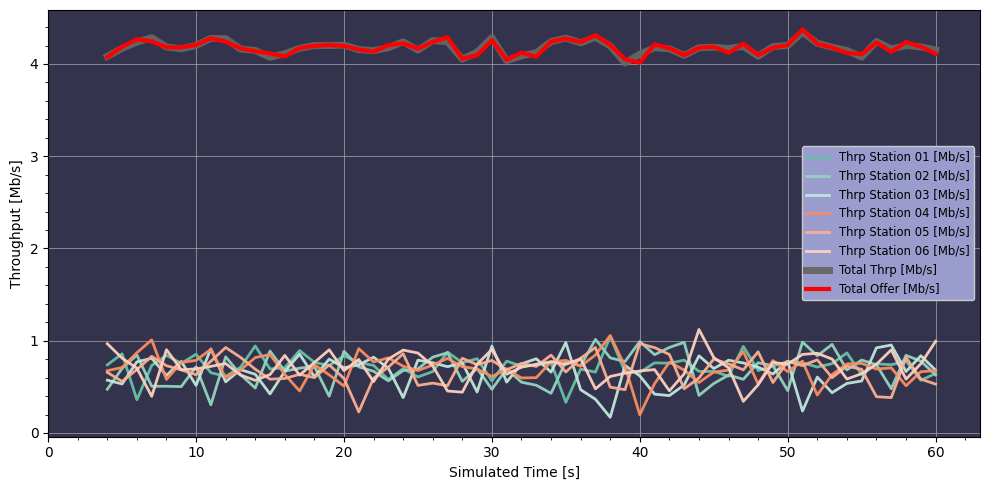

In [34]:
# --- Plot Total Results ---
fig, ax = plot_all_thrp_vs_offer()